# 07 · General Route Analysis & Error Detection

## Objective
This notebook focuses on a general assessment of the inferred trajectories and an analysis of the estimation errors to ensure data quality. The primary goals are:
1. Analyze the distribution of trip distances and time estimation errors across the entire dataset.
2. Investigate the correlation between trip length and estimation error to identify anomalies.
3. Detect and filter outliers, specifically addressing "pseudo-circular" trips (short linear distance but long duration) that skew the error metrics.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Load data

In [3]:
FILES_PATH = '../../data/processed/trips_final/'

all_trips = pd.read_parquet(FILES_PATH, columns=['distance_m', 'estimation_error_sec'])

all_trips.shape

(40954601, 2)

## General Evaluation

Initially, a general evaluation of the results derived from the inference of route behaviors and trajectories is performed. This section examines the data as a whole, without specific segmentation, to establish a baseline understanding.

### Average Trip Distance and Mean Time Error

The following calculations determine the average distance of all trips and the mean time error obtained during route inference.

In [4]:
# Mean trip distance
mean_distance = all_trips['distance_m'].mean()
print(f'Mean trip distance: {mean_distance:.2f} meters')

# Mean estimation error
mean_error = all_trips['estimation_error_sec'].mean()
print(f'Mean estimation error: {mean_error:.2f} seconds')

Mean trip distance: 2943.27 meters
Mean estimation error: 124.71 seconds


In [5]:
# Median trip distance
median_distance = all_trips['distance_m'].median()
print(f'Median trip distance: {median_distance:.2f} meters')

# Median estimation error
median_error = all_trips['estimation_error_sec'].median()   
print(f'Median estimation error: {median_error:.2f} seconds')

Median trip distance: 2274.16 meters
Median estimation error: 48.71 seconds


The average trip distance is approximately 3 km. However, the median indicates a lower value, close to 2 km. While longer trips skew the mean upwards, the median reveals that trips are generally shorter, typically falling between 2 and 3 km.

Regarding the estimation error time, the mean presents a notably high value of over 2 minutes, whereas the median sits at a more reasonable 50 seconds. This discrepancy is logical, longer trips increase the difficulty of precise time estimation. Greater duration increases the probability of unforeseen events, such as multiple traffic lights, roadworks, or traffic congestion, preventing optimal travel speeds.

To better understand and illustrate these circumstances, the following visualizations are presented. First, a pie chart displays the proportion of each trip type categorized by distance.

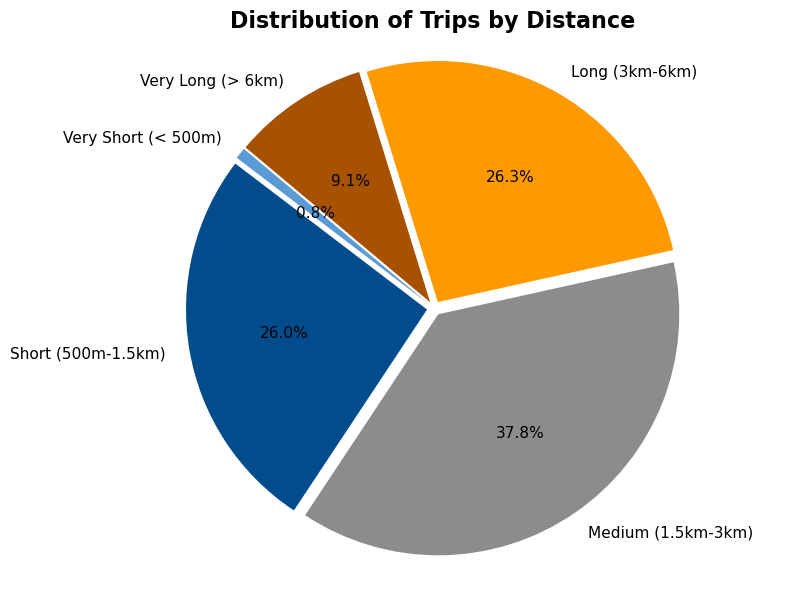

In [6]:
bins = [0, 500, 1500, 3000, 6000, float('inf')]
labels = ['Very Short (< 500m)', 'Short (500m-1.5km)', 'Medium (1.5km-3km)', 'Long (3km-6km)', 'Very Long (> 6km)']

# Segment the data
all_trips['distance_category'] = pd.cut(
    all_trips['distance_m'], 
    bins=bins, 
    labels=labels,
    right=True
)

# Calculate counts per category
category_counts = all_trips['distance_category'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
plt.pie(
    category_counts, 
    labels=category_counts.index, 
    autopct='%1.1f%%',
    startangle=140, 
    colors=["#5b9bd5","#004c8c","#8c8c8c","#ff9900","#a65200"],
    explode=(0.03, 0.03, 0.03, 0.03, 0.03),
    textprops={'fontsize': 11}
)

plt.title('Distribution of Trips by Distance', fontsize=16, fontweight='bold')
plt.axis('equal')

plt.tight_layout()
plt.show()

Nearly 40% of trips fall into the medium-distance category, aligning closest with the previously calculated mean and median. The number of trips immediately above and below this category is similar. However, the reason the mean is significantly higher than the median becomes apparent here: 9.1% of trips are classified as 'Very Long', compared to only 0.8% as 'Very Short'. Consequently, these long trips pull the mean upwards, even though they do not significantly influence the median value.

Next, to verify the hypothesis that greater trip length correlates with larger mean errors, trips are segmented into four categories. The mean error in seconds is calculated for each group.

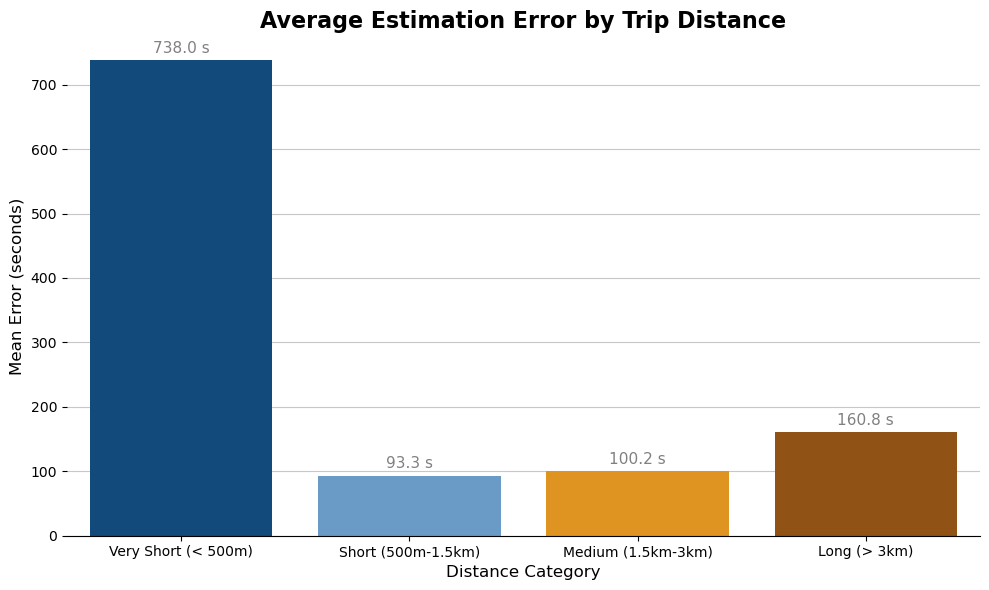

In [7]:
bins = [0, 500, 1500, 3000, float('inf')]
labels = ['Very Short (< 500m)', 'Short (500m-1.5km)', 'Medium (1.5km-3km)', 'Long (> 3km)']

# Create the category column
all_trips['dist_group_error'] = pd.cut(
    all_trips['distance_m'], 
    bins=bins, 
    labels=labels,
    right=True
)

# Calculate the Mean Estimation Error per group
mean_errors = (
    all_trips
    .groupby('dist_group_error', observed=True)
    ['estimation_error_sec']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=mean_errors, 
    x='dist_group_error', 
    y='estimation_error_sec',
    hue='dist_group_error',
    palette=["#004c8c","#5b9bd5","#ff9900","#a65200"]
)

plt.title('Average Estimation Error by Trip Distance', fontsize=16, fontweight='bold')
plt.xlabel('Distance Category', fontsize=12)
plt.ylabel('Mean Error (seconds)', fontsize=12)
sns.despine(left=True)

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f s', padding=3, fontsize=11, color='grey')

ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

This histogram reveals an interesting characteristic. It is expected that as trip length increases, the margin for delay-causing events (e.g., red lights, busy intersections, traffic) also increases. Trips categorized as 'Short', 'Medium', and 'Long' follow this premise. However, the error found in 'Very Short' trips (routes between stations less than 500 meters apart) is striking.

To better explain this case, and maintaining the assumption that shorter distances should yield smaller time errors, the proportion and quantity of very short trips with estimation errors exceeding 90 seconds are analyzed.

Total trips analyzed: 309402

Expected error (<= 90 sec): 110615 trips (35.8%)
High error (> 90 sec):  198787 trips (64.2%)


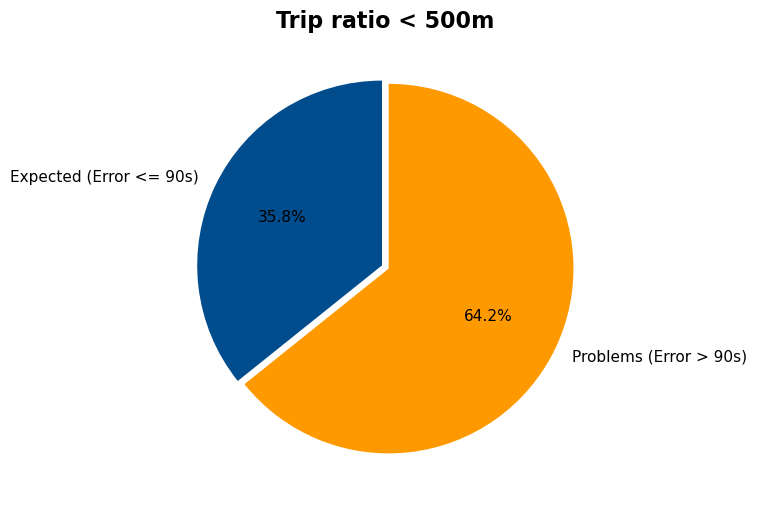

In [8]:
# Filter only the "Very Short" category
very_short_trips = all_trips[all_trips['dist_group_error'] == 'Very Short (< 500m)'].copy()

# Error less than or equal to 90 seconds
count_under_90s = len(very_short_trips[very_short_trips['estimation_error_sec'] <= 90])

# Error more than 90 seconds
count_over_90s = len(very_short_trips[very_short_trips['estimation_error_sec'] > 90])

total_very_short = len(very_short_trips)

print(f"Total trips analyzed: {total_very_short}")
print(f"\nExpected error (<= 90 sec): {count_under_90s} trips ({count_under_90s/total_very_short:.1%})")
print(f"High error (> 90 sec):  {count_over_90s} trips ({count_over_90s/total_very_short:.1%})")

plt.figure(figsize=(6, 6))
plt.pie(
    [count_under_90s, count_over_90s], 
    labels=['Expected (Error <= 90s)', 'Problems (Error > 90s)'], 
    autopct='%1.1f%%', 
    colors=["#004c8c", "#ff9900"],
    explode=(0.02, 0.02),
    startangle=90,
    textprops={'fontsize': 11}
)
plt.title('Trip ratio < 500m', fontsize=16, fontweight='bold')
plt.show()

Following the reasoning that shorter distance should imply lower error, it is found that almost 65% of trips under 500 meters (198,787 trips) have an error exceeding 90 seconds. This is counterintuitive, as such high errors in short trips do not initially make sense. The experiment is repeated with more granular data division to identify the volume of trips with excessive errors that are inflating the mean.

Total very short trips analyzed: 309402

Expected (≤ 90s): 110615 trips (35.8%)
+1 min (90-150s]: 30549 trips (9.9%)
1–5 min (150-390s]: 43608 trips (14.1%)
5–10 min (390-690s]: 28927 trips (9.3%)
Very Large Error (> 690s): 95703 trips (30.9%)


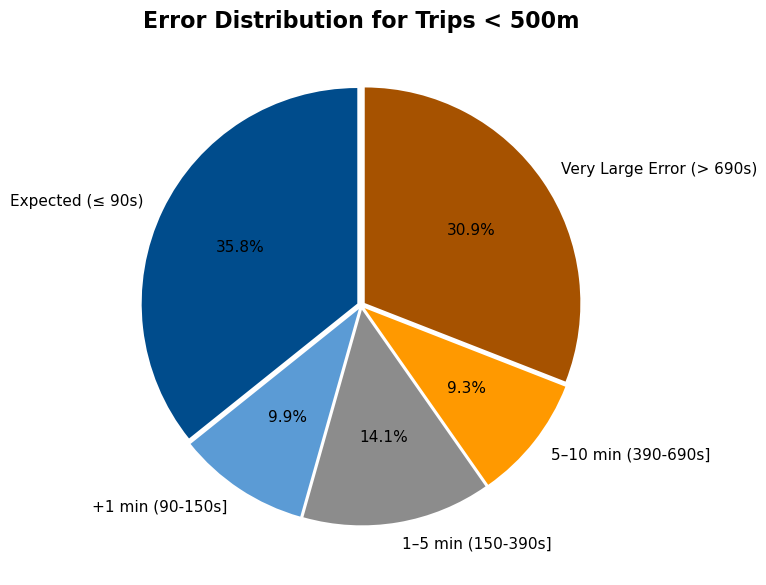

In [9]:
bins = [0, 90, 150, 390, 690, np.inf]

labels = [
    "Expected (≤ 90s)",
    "+1 min (90-150s]",
    "1–5 min (150-390s]",
    "5–10 min (390-690s]",
    "Very Large Error (> 690s)"
]

error_counts = pd.cut(
    very_short_trips['estimation_error_sec'],
    bins=bins,
    labels=labels,
    right=True
).value_counts().sort_index()

total = error_counts.sum()

print(f"Total very short trips analyzed: {total}\n")

for label, count in error_counts.items():
    print(f"{label}: {count} trips ({count/total:.1%})")

plt.figure(figsize=(7, 7))

plt.pie(
    error_counts,
    labels=error_counts.index,
    autopct='%1.1f%%',
    explode=(0.02, 0.02, 0.02, 0.02, 0.02),
    colors=["#004c8c","#5b9bd5","#8c8c8c","#ff9900","#a65200"],
    startangle=90,
    textprops={'fontsize': 11}
)

plt.title('Error Distribution for Trips < 500m', fontsize=16, fontweight='bold')
plt.show()

Several conclusions can be drawn from this final experiment. First, more than half of the trips under 500 meters have an acceptable error of less than 5 minutes. However, 40.2% of trips exhibit an unacceptable error, specifically the 30.9% with an error exceeding 10 minutes. What causes such a large error in such a short trip?

The answer lies in circular trips that were not accounted for during data cleaning. Initially, strictly circular trips (start and end at the same station) were removed, as they represent leisure rides or specific errands irrelevant to this mobility study. However, "pseudo-circular" trips were not considered. A user might start at Station A, ride for leisure, find Station A full upon return, and dock at nearby Station B. The model interprets this as a linear trip between A and B (distance < 500m), estimating a very short duration, whereas the actual usage time was much longer. This discrepancy causes the high estimation error.

Furthermore, approximately 9% of the trips in this category exhibit an estimation error ranging from 5 to 10 minutes. While less extreme than cases exceeding 10 minutes, these deviations still indicate anomalies within the service usage. These records represent A-to-B displacements characterized by significant delays, likely attributable to docking mechanism failures (at the start or end of the trip), mechanical breakdowns requiring the user to complete the route on foot, or unreported intermediate stops. While such temporal discrepancies might be statistically negligible in long-distance travel, in very short trips they constitute significant noise that compromises data quality.

Previously, neither these 'open-loop' leisure trips nor those affected by technical issues or extended stops were excluded, potentially introducing bias into prior analyses, particularly in station clustering. Consequently, a strict threshold has been established to remove very short trips with an estimation error exceeding 5 minutes. Subsequent experiments will be re-executed to verify variations and ensure maximum precision. Additionally, a statistical outlier detection method will be applied across all distance categories to systematically identify and exclude trips that deviate significantly from expected durations due to unobserved factors.